Milk Production prediction using LSTM (using Tensor flow)

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

### Load datasets and scalling

In [2]:
data = pd.read_csv('monthly_milk_production.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
production = data['Production'].astype(float).values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(production)

### Data spliting
- Sliding window of 12 is considered


In [3]:
window_size = 12
X = []
y = []
target_dates = data.index[window_size:]

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

### LSTM model

In [4]:
model = Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Model Training
- 100 Epochs

In [5]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((y_test - predictions)**2))
print(f'RMSE: {rmse:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 444ms/step - loss: 0.1417 - val_loss: 0.0286
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0332 - val_loss: 0.0300
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0297 - val_loss: 0.0643
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0361 - val_loss: 0.0437
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - loss: 0.0258 - val_loss: 0.0270
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0336 - val_loss: 0.0262
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0255 - val_loss: 0.0331
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0249 - val_loss: 0.0373
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0247 - val_loss: 0.0267
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0235 - val_loss: 0.0252
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0245 - val_loss: 0.0301
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0226 - 

### Trend of Loss 

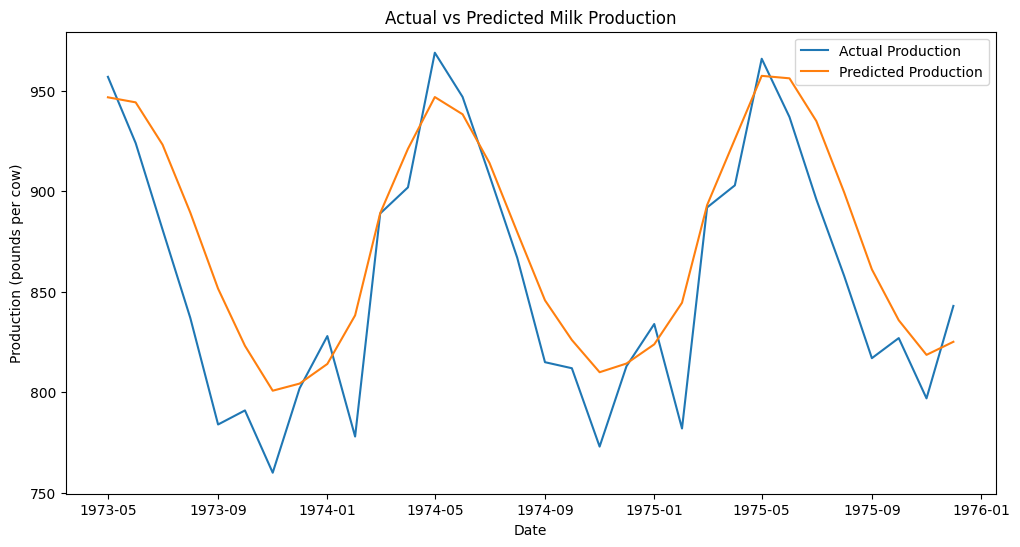

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test, label='Actual Production')
plt.plot(dates_test, predictions, label='Predicted Production')
plt.title('Actual vs Predicted Milk Production')
plt.xlabel('Date')
plt.ylabel('Production (pounds per cow)')
plt.legend()
plt.show()

### Saving models

In [9]:
model.save('milk_production_model.h5')